### Hotel Booking Cancellation Prediction

https://github.com/ravindutw

© Ravindu Wijesundara

# XGBoost

In [1]:
#import warnings
#warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np

## Import data

In [3]:
#df = pd.read_parquet("/notebooks/ML/Hotel Booking Cancellation Prediction/datasets/cleaned/hotel_bookings.parquet")
df = pd.read_parquet("/content/datasets/cleaned/hotel_bookings.parquet")

In [4]:
pd.set_option('display.max_columns', None)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86683 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           86683 non-null  object 
 1   is_canceled                     86683 non-null  int64  
 2   lead_time                       86683 non-null  int64  
 3   arrival_date_year               86683 non-null  int64  
 4   arrival_date_month              86683 non-null  object 
 5   arrival_date_week_number        86683 non-null  int64  
 6   arrival_date_day_of_month       86683 non-null  int64  
 7   stays_in_weekend_nights         86683 non-null  int64  
 8   stays_in_week_nights            86683 non-null  int64  
 9   adults                          86683 non-null  int64  
 10  children                        86683 non-null  float64
 11  babies                          86683 non-null  int64  
 12  meal                            8668

## Preprocessing

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.compose import make_column_selector
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, TargetEncoder, OrdinalEncoder, FunctionTransformer, PowerTransformer

In [7]:
target_column = 'is_canceled'

### Feature construction

In [8]:
df['arrival_date_month_num'] = pd.to_datetime(
    df['arrival_date_month'], format='%B'
).dt.month

df['arrival_date'] = pd.to_datetime(dict(
    year=df['arrival_date_year'],
    month=df['arrival_date_month_num'],
    day=df['arrival_date_day_of_month']
))

df['booking_date'] = df['arrival_date'] - pd.to_timedelta(df['lead_time'], unit='D')

REFERENCE_DATE = df['arrival_date'].max()
df['days_since_arrival'] = (REFERENCE_DATE - df['arrival_date']).dt.days

### X/y Split

In [9]:
X = df.drop(columns=[target_column])
y = df[target_column]

In [10]:
class_names = y.unique().tolist()

In [11]:
column_names = X.columns.tolist() # List all column names
numerical_cols = X.select_dtypes(include='number').columns.tolist() # List all numerical column names
cat_cols = X.select_dtypes(include=['object']).columns.tolist() # List all categorical column names

## Pipeline

### Encoding

In [12]:
drop_features = ['arrival_date_month', 'arrival_date_day_of_month']

ordinal_encode_column_features = []

# List target columns or automatically select all the remaining categorical columns
#target_encode_features = [c for c in cat_cols if c not in ordinal_encode_column_features]
target_encode_features = ['country', 'market_segment', 'distribution_channel']

# Automatically select features to one-hot encode
oh_encode_features = [c for c in cat_cols if c not in (ordinal_encode_column_features + target_encode_features)]
#oh_encode_features = []

In [13]:
ordinal_encoder = OrdinalEncoder()
ordinal_encode_column_names = [c for c in ordinal_encode_column_features if c not in drop_features]

In [14]:
target_encoder = TargetEncoder(target_type='binary', cv=5, smooth='auto', random_state=42) # Change params accordingly
target_encode_column_names = [c for c in target_encode_features if c not in drop_features]

In [15]:
oh_encoder = OneHotEncoder(sparse_output=False, drop=None, handle_unknown='ignore') # Change params accordingly
oh_encode_column_names = [c for c in oh_encode_features if c not in drop_features]

### Transformations

In [16]:
# Square root transformation
sqrt_transform_columns = ['lead_time']
sqrt_transformer = FunctionTransformer(
    func=np.sqrt,
    inverse_func=np.square,
    feature_names_out='one-to-one',
    validate=True
)

In [17]:
# Box-cox transformation
boxcox_transform_columns = ['stays_in_week_nights', 'adults', 'previous_cancellations', 'previous_bookings_not_canceled',
                           'agent', 'adr']
boxcox_transformer = PowerTransformer(method='yeo-johnson', standardize=True)

In [18]:
# Log transformation
log_transform_columns = []
log_transformer = FunctionTransformer(
    func=np.log1p,
    inverse_func=np.expm1,
    feature_names_out='one-to-one',
    validate=True
)

### Passthrough

In [19]:
non_stationary_features = ['arrival_date_year']

pass_through_features = [
    c for c in numerical_cols
    if c not in (sqrt_transform_columns + boxcox_transform_columns
                 + log_transform_columns + non_stationary_features)
]

print(pass_through_features)

['arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'children', 'babies', 'is_repeated_guest', 'booking_changes', 'company', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests', 'arrival_date_month_num', 'days_since_arrival']


### Preprocessor

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        #('ordinal_enc', ordinal_encoder, ordinal_encode_column_names),
        ('target_enc', target_encoder, target_encode_column_names),
        ('oh_enc', oh_encoder, oh_encode_column_names),
        ('sqrt_transform', sqrt_transformer, sqrt_transform_columns),
        ('boxcox_transform', boxcox_transformer, boxcox_transform_columns),
        #('log_transform', log_transformer, log_transform_columns),
        ('passthrough', 'passthrough', pass_through_features)
    ],
    remainder='drop', # Drop everything that are not in the transformer
    verbose_feature_names_out=True
)

# Comment-out unncecessary transformers

In [21]:
# Encode y
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

### Temporal train-test split

In [22]:
SPLIT_COLUMN = 'arrival_date'
TEST_FRAC = 0.20
VAL_FRAC  = 0.15

dates = X[SPLIT_COLUMN]

test_cutoff = dates.quantile(1 - TEST_FRAC).normalize()
test_mask = dates >= test_cutoff

trainval_dates = dates[~test_mask]
val_cutoff = trainval_dates.quantile(1 - VAL_FRAC).normalize()

val_mask   = (~test_mask) & (dates >= val_cutoff)
train_mask = (~test_mask) & (dates <  val_cutoff)

X_train, y_train = X[train_mask], y[train_mask.to_numpy()]
X_val,   y_val   = X[val_mask],   y[val_mask.to_numpy()]
X_test,  y_test  = X[test_mask],  y[test_mask.to_numpy()]

for name, Xs, ys in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    print(f"{name:<6} {Xs.shape[0]:>7,} rows   "
          f"{Xs[SPLIT_COLUMN].min().date()} -> {Xs[SPLIT_COLUMN].max().date()}   "
          f"cancel rate {ys.mean():.3f}")

train   58,806 rows   2015-07-01 -> 2017-02-09   cancel rate 0.249
val     10,513 rows   2017-02-10 -> 2017-05-02   cancel rate 0.294
test    17,364 rows   2017-05-03 -> 2017-08-31   cancel rate 0.346


### Drop outliers only from train data

In [23]:
outlier_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights']

q1 = X_train[outlier_cols].quantile(0.25)
q3 = X_train[outlier_cols].quantile(0.75)
iqr = q3 - q1

In [24]:
condition = ~((X_train[outlier_cols] < (q1 - 1.5 * iqr)) |
              (X_train[outlier_cols] > (q3 + 1.5 * iqr))).any(axis=1)

X_train = X_train[condition]
y_train = y_train[condition.to_numpy()]

In [25]:
X_train.shape

(53054, 33)

In [26]:
y_train.shape

(53054,)

## Hyper-parameter search



In [27]:
#!pip install optuna optuna-integration

In [28]:
from xgboost import XGBClassifier
import optuna
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

In [29]:
try:
    from optuna_integration.xgboost import XGBoostPruningCallback
except ImportError:
    XGBoostPruningCallback = None

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [30]:
tuning_preprocessor = clone(preprocessor)

X_train_enc = tuning_preprocessor.fit_transform(X_train, y_train)
X_val_enc   = tuning_preprocessor.transform(X_val)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(


In [31]:
SEED = 42
N_TRIALS = 50
MAX_ROUNDS = 3000
EARLY_STOPPING_ROUNDS = 50
DEVICE = 'cpu'
RECENCY_HALFLIFE_DAYS = 180
DECISION_THRESHOLD = 0.6

In [32]:
age_days = (X_train[SPLIT_COLUMN].max() - X_train[SPLIT_COLUMN]).dt.days.to_numpy()
train_weights = 0.5 ** (age_days / RECENCY_HALFLIFE_DAYS)

In [33]:
def objective(trial):
    params = {
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma':             trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight':  trial.suggest_float('scale_pos_weight', 0.5, 4.0, log=True),
    }

    callbacks = []
    if XGBoostPruningCallback is not None:
        callbacks.append(XGBoostPruningCallback(trial, 'validation_0-auc'))

    model = XGBClassifier(
        n_estimators=MAX_ROUNDS,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        eval_metric='auc',
        objective='binary:logistic',
        tree_method='hist',
        device=DEVICE,
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
        callbacks=callbacks,
        **params
    )

    model.fit(X_train_enc, y_train,
              sample_weight=train_weights,
              eval_set=[(X_val_enc, y_val)], verbose=False)

    trial.set_user_attr('best_iteration', int(model.best_iteration))

    val_proba = model.predict_proba(X_val_enc)[:, 1]
    return roc_auc_score(y_val, val_proba)

In [34]:
study = optuna.create_study(
    study_name='xgb_hotel_cancellation',
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=50)
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]

In [35]:
best_params = study.best_params
best_n_estimators = int(study.best_trial.user_attrs['best_iteration']) + 1

print(f"Best validation ROC-AUC : {study.best_value:.4f}")
print(f"Best n_estimators       : {best_n_estimators}")
print("Best params:")
for k, v in best_params.items():
    print(f"  {k:<18}: {v}")

Best validation ROC-AUC : 0.8839
Best n_estimators       : 128
Best params:
  learning_rate     : 0.08330803890301997
  max_depth         : 6
  min_child_weight  : 2
  subsample         : 0.6554911608578311
  colsample_bytree  : 0.5951099932160482
  gamma             : 0.022224001634839095
  reg_alpha         : 0.005470376807480391
  reg_lambda        : 0.9658611176861268
  scale_pos_weight  : 1.3348195997170238


## Model - XGBoost

In [36]:
xgb_model = XGBClassifier(
    **best_params,
    n_estimators=int(best_n_estimators * 1.1),
    objective='binary:logistic',
    tree_method='hist',
    device=DEVICE,
    random_state=SEED,
    n_jobs=-1,
    verbosity=1
)

In [37]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    #('drop_low_variance', drop_low_var_cols),
    ('xgb', xgb_model)
])

In [38]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = np.concatenate([y_train, y_val])

In [39]:
age_final = (X_train_final[SPLIT_COLUMN].max() - X_train_final[SPLIT_COLUMN]).dt.days.to_numpy()
final_weights = 0.5 ** (age_final / RECENCY_HALFLIFE_DAYS)

In [40]:
pipeline.fit(X_train_final, y_train_final, xgb__sample_weight=final_weights)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('target_enc',
                                                  TargetEncoder(random_state=42,
                                                                target_type='binary'),
                                                  ['country', 'market_segment',
                                                   'distribution_channel']),
                                                 ('oh_enc',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['hotel', 'meal',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type']),
                                                 ('sqrt_...
                               gamma=0.022224001634839095, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.08330803890301997, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=6,
                               max_leaves=None, min_child_weight=2, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=140, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## Evaluation

In [41]:
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_auc_score, accuracy_score)
import numpy as np
import matplotlib.pyplot as plt

In [42]:
proba = pipeline.predict_proba(X_test)[:, 1]
preds = (proba >= DECISION_THRESHOLD).astype(int)

In [43]:
def test_model(y_test, y_pred, class_names):

  print("Classification Report:")
  print(classification_report(y_test, y_pred, target_names=class_names))

  cm = confusion_matrix(y_test, y_pred)

  print("Confusion Matrix:")

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
  disp.plot(cmap=plt.cm.plasma)
  plt.title("Confusion matrix")
  plt.show()



Classification Report:
               precision    recall  f1-score   support

not_cancelled       0.84      0.84      0.84     11360
    cancelled       0.70      0.70      0.70      6004

     accuracy                           0.79     17364
    macro avg       0.77      0.77      0.77     17364
 weighted avg       0.79      0.79      0.79     17364

Confusion Matrix:


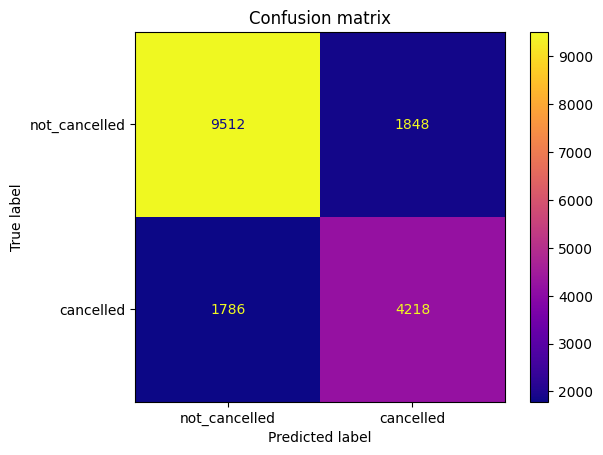

In [44]:
test_model(y_test, preds, ['not_cancelled', 'cancelled'])

In [45]:
print(f"ROC-AUC          : {roc_auc_score(y_test, proba):.4f}")
print(f"accuracy (0.50)  : {accuracy_score(y_test, (proba >= 0.5).astype(int)):.4f}")
print(f"accuracy ({DECISION_THRESHOLD:.2f})  : {accuracy_score(y_test, preds):.4f}")

ROC-AUC          : 0.8692
accuracy (0.50)  : 0.7816
accuracy (0.60)  : 0.7907
